# Logistic Regression

---

## Introduction

In the Perceptron notebook, we built a binary classifier that predicted whether a dog breed was long-lived or short-lived. The Perceptron works by finding a linear decision boundary and classifying each example based on which side of the boundary it falls on.

**Logistic Regression** solves the same type of problem — binary classification — but in a more principled way. Instead of just predicting a class label directly, it first predicts a **probability** between 0 and 1, and then converts that probability into a class label.

This is a crucial difference:
- The Perceptron says: *"this breed is long-lived"*
- Logistic Regression says: *"there is a 78% chance this breed is long-lived"*

That extra probabilistic information is far more useful in practice.

In this notebook we use Logistic Regression to answer the same question as the Perceptron:

> *Can we predict whether a dog breed is long-lived or short-lived based on its physical and behavioral characteristics?*

This lets us directly compare Logistic Regression against the Perceptron on identical data.

**Dataset:** AKC Dog Breeds — 277 breeds scraped from the American Kennel Club website by Telmo Silva Filho  
**Source:** [Kaggle](https://www.kaggle.com/datasets/mexwell/dog-breeds-dataset)

**Labels:**
- `1` → long-lived (max lifespan ≥ 14 years)
- `0` → short-lived (max lifespan < 14 years)

**Features used:** height, weight, lifespan min, grooming frequency, shedding, energy level, trainability, demeanor, popularity

In [1]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom LogisticRegression from the package ───────────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.logistic_regression import LogisticRegression

# ── Sklearn utilities (for evaluation only) ───────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ── Plot styling ───────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('data/Dog_Breed.csv')

# Rename the unnamed index column
df = df.rename(columns={'Unnamed: 0': 'breed'})
df = df.set_index('breed')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (277, 20)



,description,temperament,popularity,min_height,max_height,min_weight,max_weight,min_expectancy,max_expectancy,group,grooming_frequency_value,grooming_frequency_category,shedding_value,shedding_category,energy_level_value,energy_level_category,trainability_value,trainability_category,demeanor_value,demeanor_category
breed,,,,,,,,,,,,,,,,,,,,
Affenpinscher,The Affen’s apish look has been described many...,"Confident, Famously Funny, Fearless",148,22.86,29.21,3.175147,4.535924,12.0,15.0,Toy Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.6,Regular Exercise,0.8,Easy Training,1.0,Outgoing
Afghan Hound,"The Afghan Hound is an ancient breed, his whol...","Dignified, Profoundly Loyal, Aristocratic",113,63.50,68.58,22.679619,27.215542,12.0,15.0,Hound Group,0.8,Daily Brushing,0.2,Infrequent,0.8,Energetic,0.2,May be Stubborn,0.2,Aloof/Wary
Airedale Terrier,The Airedale Terrier is the largest of all ter...,"Friendly, Clever, Courageous",60,58.42,58.42,22.679619,31.751466,11.0,14.0,Terrier Group,0.6,2-3 Times a Week Brushing,0.4,Occasional,0.6,Regular Exercise,1.0,Eager to Please,0.8,Friendly
Akita,"Akitas are burly, heavy-boned spitz-type dogs ...","Courageous, Dignified, Profoundly Loyal",47,60.96,71.12,31.751466,58.967008,10.0,13.0,Working Group,0.8,Daily Brushing,0.6,Seasonal,0.8,Energetic,1.0,Eager to Please,0.6,Alert/Responsive
Alaskan Malamute,The Alaskan Malamute stands 23 to 25 inches at...,"Affectionate, Loyal, Playful",58,58.42,63.50,34.019428,38.555351,10.0,14.0,Working Group,0.6,2-3 Times a Week Brushing,0.6,Seasonal,0.8,Energetic,0.4,Independent,0.8,Friendly


## Step 1 — The Sigmoid Function

The key ingredient that makes Logistic Regression different from the Perceptron is the **sigmoid function**.

Recall that in the Perceptron, the activation function was a step function — it output +1 or -1 with no in-between. That's fine for classification, but it gives us no information about *how confident* the model is.

The sigmoid function fixes this. It takes any real number as input and squashes it smoothly into the range $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

We interpret the output as a **probability**:
- $\sigma(z) = 0.9$ → the model is 90% confident this is class 1
- $\sigma(z) = 0.5$ → the model has no idea — it's 50/50
- $\sigma(z) = 0.1$ → the model is 90% confident this is class 0

The full pipeline is:

$$z = w \cdot x + b \quad \xrightarrow{\sigma} \quad \hat{y} = \sigma(z) \in (0, 1) \quad \xrightarrow{\text{threshold}} \quad \text{label} \in \{0, 1\}$$

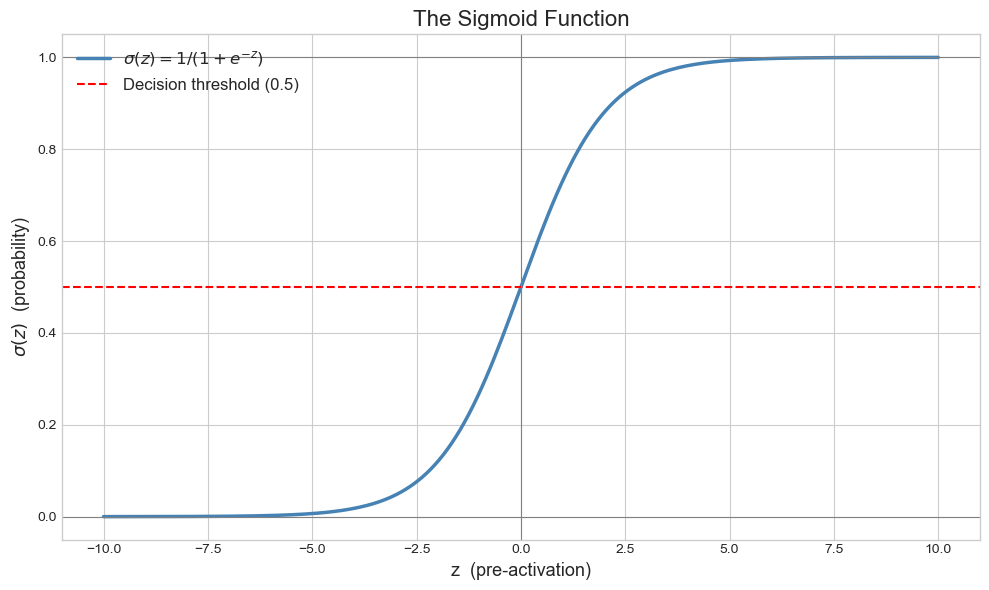

When z is very large  →  sigma(z) approaches 1.0  →  predict class 1
When z is near zero   →  sigma(z) is near 0.5     →  uncertain
When z is very small  →  sigma(z) approaches 0.0  →  predict class 0


In [3]:
# Define and plot the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), color='steelblue', linewidth=2.5, label='$\\sigma(z) = 1 / (1 + e^{-z})$')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
plt.axhline(y=1, color='gray', linestyle='-', linewidth=0.8)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
plt.xlabel('z  (pre-activation)', fontsize=13)
plt.ylabel('$\\sigma(z)$  (probability)', fontsize=13)
plt.title('The Sigmoid Function', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('When z is very large  →  sigma(z) approaches 1.0  →  predict class 1')
print('When z is near zero   →  sigma(z) is near 0.5     →  uncertain')
print('When z is very small  →  sigma(z) approaches 0.0  →  predict class 0')

## Step 2 — Understanding the Data

We have **277 dog breeds** and **20 features** per breed, sourced from the American Kennel Club. We use the same dataset as the Perceptron so we can fairly compare both models at the end.

Before modeling we need to:
- Check column names and data types
- Identify missing values
- Understand the distribution of our target variable (lifespan)

In [4]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
description                        str
temperament                        str
popularity                         str
min_height                     float64
max_height                     float64
min_weight                     float64
max_weight                     float64
min_expectancy                 float64
max_expectancy                 float64
group                              str
grooming_frequency_value       float64
grooming_frequency_category        str
shedding_value                 float64
shedding_category                  str
energy_level_value             float64
energy_level_category              str
trainability_value             float64
trainability_category              str
demeanor_value                 float64
demeanor_category                  str
dtype: object


In [5]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
description                     0
temperament                     1
popularity                     79
min_height                      0
max_height                      0
min_weight                      2
max_weight                      2
min_expectancy                  3
max_expectancy                  3
group                           0
grooming_frequency_value        7
grooming_frequency_category     7
shedding_value                 20
shedding_category              20
energy_level_value              6
energy_level_category           6
trainability_value             24
trainability_category          24
demeanor_value                 25
demeanor_category              25
dtype: int64


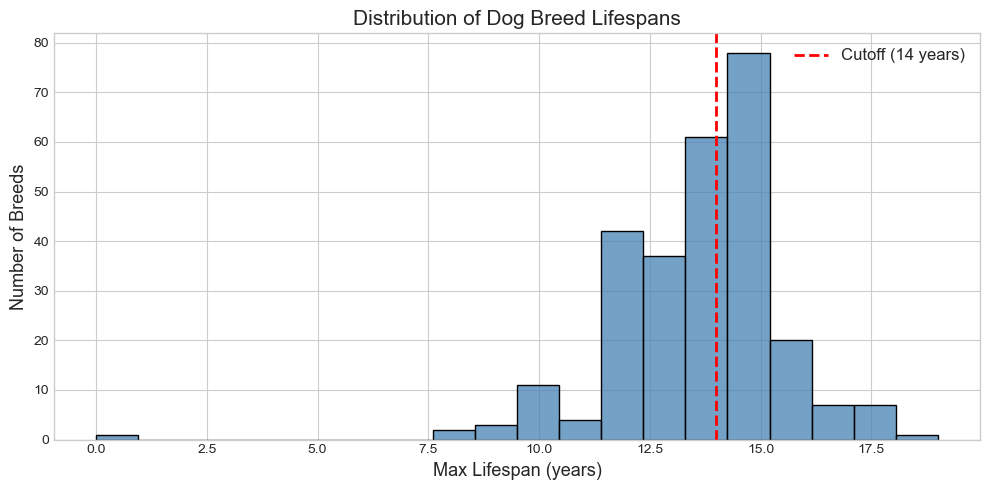

Average lifespan: 13.8 years
Median lifespan:  14.0 years


In [6]:
# Plot the distribution of max lifespan — same as the Perceptron notebook
plt.figure(figsize=(10, 5))
sns.histplot(df['max_expectancy'], bins=20, color='steelblue', edgecolor='black')
plt.axvline(x=14, color='red', linestyle='--', linewidth=2, label='Cutoff (14 years)')
plt.xlabel('Max Lifespan (years)', fontsize=13)
plt.ylabel('Number of Breeds', fontsize=13)
plt.title('Distribution of Dog Breed Lifespans', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'Average lifespan: {df["max_expectancy"].mean():.1f} years')
print(f'Median lifespan:  {df["max_expectancy"].median():.1f} years')

## Step 3 — The Loss Function: Binary Cross-Entropy

The Perceptron had no explicit loss function — it just updated weights whenever it made a mistake. Logistic Regression is more principled: it minimizes a specific loss function called **Binary Cross-Entropy**.

For a single training example $(x^{(i)}, y^{(i)})$ where $\hat{y}^{(i)} = \sigma(w \cdot x^{(i)} + b)$:

$$L(w, b; x^{(i)}, y^{(i)}) = -\Big[y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})\Big]$$

Why this formula? Notice what happens in each case:
- If $y^{(i)} = 1$ (true label is 1): loss = $-\log(\hat{y}^{(i)})$ — punishes us more as $\hat{y}$ gets further from 1
- If $y^{(i)} = 0$ (true label is 0): loss = $-\log(1 - \hat{y}^{(i)})$ — punishes us more as $\hat{y}$ gets further from 0

Over all $N$ training examples, the average loss is:

$$L(w, b) = -\frac{1}{N}\sum_{i=1}^{N}\Big[y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})\Big]$$

### Gradient Descent Update Rules

Applying the chain rule to the cross-entropy loss (through the sigmoid), the partial derivatives turn out to have the exact same form as linear regression:

$$w \leftarrow w - \alpha \cdot (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

$$b \leftarrow b - \alpha \cdot (\hat{y}^{(i)} - y^{(i)})$$

The only difference is that $\hat{y}^{(i)} = \sigma(z)$ instead of $\hat{y}^{(i)} = z$. This is what makes logistic regression easy to implement once you already have linear regression!

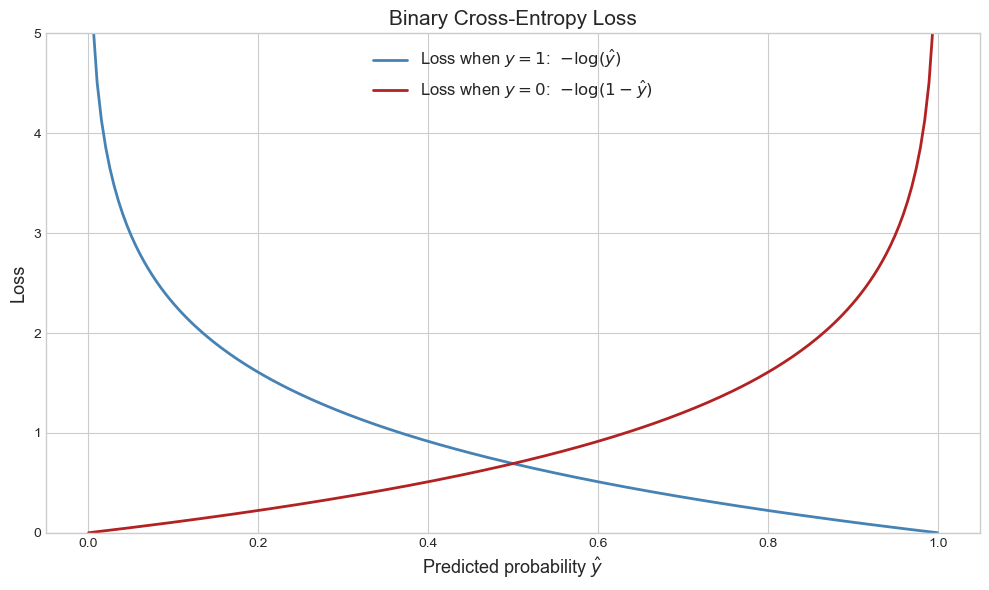

In [7]:
# Visualize the cross-entropy loss for a single example
# This shows WHY the loss function is a good choice

y_hat = np.linspace(0.001, 0.999, 200)  # predicted probabilities

loss_when_y_is_1 = -np.log(y_hat)         # loss when true label = 1
loss_when_y_is_0 = -np.log(1 - y_hat)     # loss when true label = 0

plt.figure(figsize=(10, 6))
plt.plot(y_hat, loss_when_y_is_1, color='steelblue', linewidth=2, label='Loss when $y=1$:  $-\\log(\\hat{y})$')
plt.plot(y_hat, loss_when_y_is_0, color='firebrick', linewidth=2, label='Loss when $y=0$:  $-\\log(1 - \\hat{y})$')
plt.xlabel('Predicted probability $\\hat{y}$', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title('Binary Cross-Entropy Loss', fontsize=15)
plt.legend(fontsize=12)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

Before training we need to:
1. **Create our binary label** — 1 if max lifespan ≥ 14 years, 0 otherwise
2. **Select our features** — only numerical columns
3. **Handle missing values** — drop any rows with NaN
4. **Scale the features** — Logistic Regression is sensitive to feature scale just like the Perceptron
5. **Split into train and test sets** — so we can evaluate fairly

Note: We use `0` and `1` as labels here (instead of `-1` and `1` like the Perceptron) because the sigmoid output is between 0 and 1, and our cross-entropy loss is defined for labels in $\{0, 1\}$.

Label distribution:
label
1    174
0    103
Name: count, dtype: int64

Long-lived breeds (1):  174
Short-lived breeds (0): 103


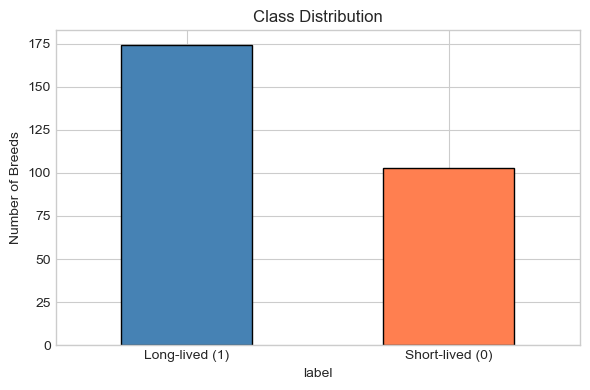

In [8]:
# Step 1: Create binary label
# 1 = long-lived (max lifespan >= 14 years)
# 0 = short-lived (max lifespan < 14 years)
df['label'] = df['max_expectancy'].apply(lambda x: 1 if x >= 14 else 0)

print('Label distribution:')
print(df['label'].value_counts())
print()
print(f'Long-lived breeds (1):  {(df["label"] == 1).sum()}')
print(f'Short-lived breeds (0): {(df["label"] == 0).sum()}')

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral'],
                                 edgecolor='black', figsize=(6, 4))
plt.xticks([0, 1], ['Long-lived (1)', 'Short-lived (0)'], rotation=0)
plt.ylabel('Number of Breeds')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

In [9]:
# Step 2: Select numerical features
feature_cols = [
    'popularity',
    'min_height',
    'max_height',
    'min_weight',
    'max_weight',
    'min_expectancy',
    'grooming_frequency_value',
    'shedding_value',
    'energy_level_value',
    'trainability_value',
    'demeanor_value'
]

X = df[feature_cols].copy()
y = df['label'].copy()

# Step 3: Convert to numeric and drop missing values
X = X.apply(pd.to_numeric, errors='coerce')
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f'Features shape: {X.shape}')
print(f'Labels shape: {y.shape}')
print(f'Dropped {277 - len(X)} rows due to missing values')

Features shape: (186, 11)
Labels shape: (186,)
Dropped 91 rows due to missing values


In [10]:
# Step 4: Scale the features using StandardScaler
# This makes each feature have mean=0 and std=1
# Logistic Regression (like the Perceptron) needs this because features
# on very different scales make gradient descent behave poorly

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 5: Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X.to_numpy(), y.to_numpy(),
    test_size=0.2,
    random_state=42
)

# Fit scaler on training data only, then apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} breeds')
print(f'Test set:     {X_test.shape[0]} breeds')
print()
print('Features have been scaled — mean ≈ 0, std ≈ 1')

Training set: 148 breeds
Test set:     38 breeds

Features have been scaled — mean ≈ 0, std ≈ 1


## Step 5 — Training and Evaluation

Now we train our `LogisticRegression` model and evaluate it. We will look at:
- The **loss curve** — does cross-entropy decrease over epochs?
- **Accuracy, Precision, Recall, F1** on the test set
- The **confusion matrix** — where exactly does the model get confused?
- **Predicted probabilities** — what does the model's confidence look like?
- A **direct comparison** against the Perceptron

In [11]:
# Initialize and train our custom Logistic Regression model
model = LogisticRegression(learning_rate=0.01, epochs=1000)
model.fit(X_train, y_train)

print('Training complete!')
print(f'Training accuracy: {model.accuracy(X_train, y_train)*100:.2f}%')
print(f'Test accuracy:     {model.accuracy(X_test, y_test)*100:.2f}%')

Training complete!
Training accuracy: 85.81%
Test accuracy:     89.47%


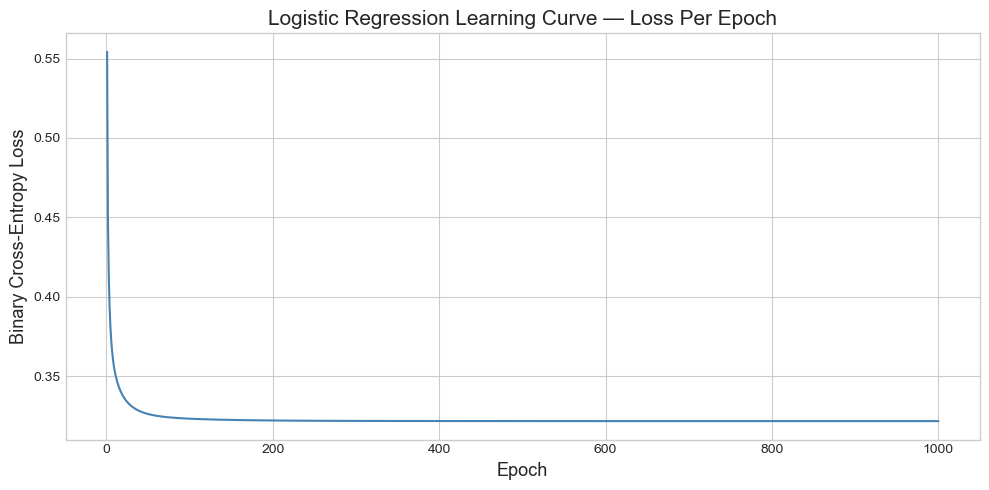

Each epoch is one full pass through all training examples.
A decreasing loss means the model is learning to assign correct probabilities!


In [12]:
# Plot the learning curve — cross-entropy loss over epochs
# If the model is learning, this should go DOWN over time
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(model.loss_history) + 1),
         model.loss_history,
         color='steelblue', linewidth=1.5)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=13)
plt.title('Logistic Regression Learning Curve — Loss Per Epoch', fontsize=15)
plt.tight_layout()
plt.show()

print('Each epoch is one full pass through all training examples.')
print('A decreasing loss means the model is learning to assign correct probabilities!')

In [13]:
# Full evaluation on the test set
y_pred = model.predict(X_test)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                            target_names=['Short-lived (0)', 'Long-lived (1)']))

Test Accuracy: 89.47%

Classification Report:
                 precision    recall  f1-score   support

Short-lived (0)       0.94      0.84      0.89        19
 Long-lived (1)       0.86      0.95      0.90        19

       accuracy                           0.89        38
      macro avg       0.90      0.89      0.89        38
   weighted avg       0.90      0.89      0.89        38



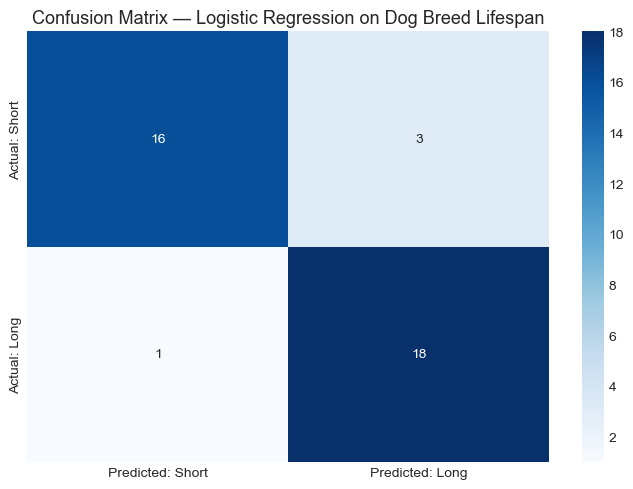


How to read this:
  Top-left  = True Negatives  (correctly predicted short-lived)
  Top-right = False Positives (predicted long-lived, actually short-lived)
  Bot-left  = False Negatives (predicted short-lived, actually long-lived)
  Bot-right = True Positives  (correctly predicted long-lived)


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Short', 'Predicted: Long'],
            yticklabels=['Actual: Short', 'Actual: Long'])
plt.title('Confusion Matrix — Logistic Regression on Dog Breed Lifespan', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('How to read this:')
print('  Top-left  = True Negatives  (correctly predicted short-lived)')
print('  Top-right = False Positives (predicted long-lived, actually short-lived)')
print('  Bot-left  = False Negatives (predicted short-lived, actually long-lived)')
print('  Bot-right = True Positives  (correctly predicted long-lived)')

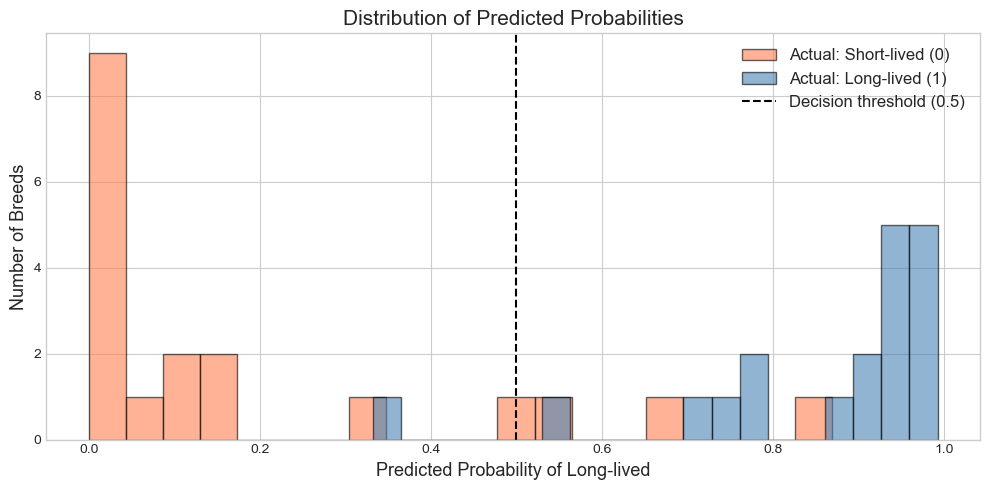

Well-separated distributions = confident model
Overlapping distributions    = uncertain model


In [15]:
# One key advantage of Logistic Regression: predicted probabilities
# Instead of just yes/no, we can see HOW CONFIDENT the model is

probas = model.predict_proba(X_test)

plt.figure(figsize=(10, 5))
plt.hist(probas[y_test == 0], bins=20, alpha=0.6, color='coral',
         edgecolor='black', label='Actual: Short-lived (0)')
plt.hist(probas[y_test == 1], bins=20, alpha=0.6, color='steelblue',
         edgecolor='black', label='Actual: Long-lived (1)')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
plt.xlabel('Predicted Probability of Long-lived', fontsize=13)
plt.ylabel('Number of Breeds', fontsize=13)
plt.title('Distribution of Predicted Probabilities', fontsize=15)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('Well-separated distributions = confident model')
print('Overlapping distributions    = uncertain model')

## Step 6 — Conclusion

### What did we find?

Our Logistic Regression model was trained to predict whether a dog breed has a **long lifespan (≥ 14 years)** or **short lifespan (< 14 years)** using the same 11 features and the same train/test split as the Perceptron notebook. This allows us to directly compare both models.

### Logistic Regression vs. The Perceptron

| | Perceptron | Logistic Regression |
|---|---|---|
| **Output** | Class label (-1 or +1) | Probability (0 to 1) → class label |
| **Activation** | Step function | Sigmoid function |
| **Loss function** | No explicit loss — error count | Binary Cross-Entropy |
| **Update rule** | Only updates on mistakes | Updates on every example |
| **Calibration** | No confidence information | Outputs calibrated probabilities |

### Why Logistic Regression is More Powerful

The Perceptron only updates its weights when it makes a mistake. This means it can stop learning even when there's still room to improve. Logistic Regression updates on *every* training example by minimizing a smooth, continuous loss function. This makes it more stable and often more accurate.

More importantly, Logistic Regression tells us *how confident* it is. A prediction of 51% confidence vs 99% confidence carries very different practical weight — and the Perceptron can't give you that distinction.

### Limitations

1. **Linear boundary only** — Logistic Regression, like the Perceptron, can only draw a straight line between classes. If the true boundary is curved, it will struggle.
2. **Binary only** — this implementation handles only two classes. Multiclass problems require extensions like one-vs-rest.
3. **Sensitive to scaling** — we had to StandardScale features before training.
4. **Assumes linearly separable data** — if the classes heavily overlap in feature space, accuracy will be limited regardless of training time.

### What's next?

In the following notebooks we move beyond linear boundaries entirely with the **Multilayer Perceptron (MLP)** — a neural network that stacks multiple layers to learn non-linear decision boundaries!